# Homework 3: Bayesian Models and Monte Carlo

BEE 4850/5850, Spring 2025

**Name**: Christine Swanson

**ID**: cms549

> **Due Date**
>
> Friday, 3/14/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practice developing and
working with probability models for data.

-   Problem 1 asks you to quantify uncertainties for a simple model
    using Bayesian statistics and rejection sampling.
-   Problem 2 asks you to use Monte Carlo simulation to calculate annual
    expected flooding damages.
-   Problem 3 (only required for students in BEE 5850) asks you to
    conduct cost-benefit analyses of housing elevation levels under
    future flooding uncertainty using Monte Carlo simulations.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [238]:
# commented out - using Python 
#import Pkg
#Pkg.activate(@__DIR__)
#Pkg.instantiate()

The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [239]:
# load Python packages (from ChatGPT)
import random  # random number generation and seed-setting
import pandas as pd  # tabular data structure
import csv  # reads/writes .csv files (optional, since pandas can handle CSVs)
import numpy as np  # numerical operations
import matplotlib.pyplot as plt  # plotting library
import scipy.stats as stats  # interface to work with probability distributions
import statistics  # statistical quantities like mean, median, etc.
import seaborn as sns  # additional statistical plotting tools
from scipy.optimize import minimize  # optimization tools 
import pymc as pm  # Bayesian modeling tools
from scipy.stats import binom # binomial distribution

## Problems

### Scoring

-   Problem 1 is worth 13 points.
-   Problem 2 is worth 7 points.
-   Problem 3 is worth 5 points.

### Problem 1

Consider the class-cheating testing procedure from [Homework
1](https://viveks.me/simulation-data-analysis/hw/hw01.html). As a
reminder, the procedure is as follows:

> Each student flips a fair coin, with the results hidden from the
> interviewer. The student answers honestly if the coin comes up heads.
> Otherwise, if the coin comes up tails, the student flips the coin
> again, and answers “I did cheat” if heads, and “I did not cheat”, if
> tails.

Suppose that, after conducting the procedure on your class of 100
students, you get 40 “Yes, I cheated” responses. You are skeptical that
your class is broadly engaged in cheating and have a prior belief that
the probability of cheating $\theta$ is unlikely to be high. We’ll
express this prior using a beta distribution, $Beta(3, 40)$, which is shown
below. You would like to understand the range of cheating propensity
which is consistent with your prior beliefs and the outcomes from the
detection procedure.

**In this problem**:

-   Construct a Bayesian probability model (based on the data-generating
    process from Homework 1 and our prior on the cheating probability)
    for the “Yes, I cheated” counts. You can compute the likelihood
    based on the combination of the fair coin flip and the “true”
    cheating probability $\theta$.
-   Plot the posterior $p(\theta | y)$ using a grid approximation
    (looping over values of $\theta$).
-   Use rejection sampling to draw 1,000 samples from the posterior and
    plot the distribution of samples. How well are you capturing the
    posterior you obtained from the grid approximation? Would you prefer
    to have more samples?
-   Report the expected value of $\theta$ and its 90% credible interval.
    What conclusions can you draw about cheating probability and whether
    your belief in your class was warranted? How much uncertainty exists
    as a result of this privacy-protecting procedure?
-   Repeat the analysis with a less constrained prior of your choosing.
    How does that change your inferences and conclusions? What does this
    tell you about the effectiveness of the procedure?



In [240]:
# set the seed at the beginning of the script to ensure reproducibility
np.random.seed(42)

### **(a) Bayesian Probability Model**

In [241]:
# code below adapted from slide 23, class notes on Bayesian stats 

# step 0: define parameters of problem
n_students = 100
n_yes = 40  # number of "yes, I cheated" responses

# step 1: define the log-likelihood function 
def flip_ll(theta):

    p_yes = 0.5 * theta + 0.25  # probability of responding "yes"
    # 0.5 is the probability of the first coin flip being heads (truthful response)
    # 0.25 comes from the second flip (0.5 probability of tails, followed by 0.5 probability of heads -> p=0.25)

    # model the numner of "yes, I cheated" responses as a binomial RV
    log_likelihood = binom.logpmf(n_yes, n_students, p_yes) 
    return log_likelihood 

# step 2: define the prior -> here, Beta(3, 40)
def flip_log_prior(theta):
    beta_prior = np.log(stats.beta.pdf(theta, a=3, b=40)) 
    return beta_prior

# step 3: define the posterior
def flip_log_posterior(theta):
    # posterior is proportional to likelihood * prior (here, using logs, so sum)
    posterior = flip_ll(theta) + flip_log_prior(theta) 
    return posterior

### **(b) Plot the Posterior**

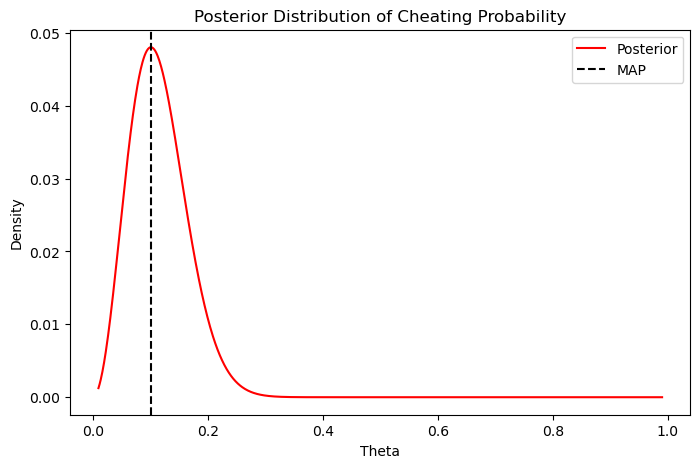

In [242]:
# adapted from slide 23, class notes on Bayesian stats

# find the MAP by maximizing log posterior

# scipy.optimize.minimize documentation: https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html
result = minimize(lambda theta: -flip_log_posterior(theta), x0=0.1, bounds=[(0, 1)])
theta_map = result.x[0]

# compute posterior distribution for plotting
theta_values = np.linspace(0.01, 0.99, 1000) # grid approx approach (here, 1000 values between 0.01 and 0.99)

# compute the posterior values
# note: we exponentiate here because the posterior is in log form, 
# so convert back to normal space for plotting
posterior_values = np.exp([flip_log_posterior(theta) for theta in theta_values])

# plot the posterior
plt.figure(figsize=(8, 5))

plt.plot(theta_values, posterior_values, label="Posterior", color="red")
plt.axvline(theta_map, color="black", linestyle="--", label="MAP")
plt.xlabel("Theta")
plt.ylabel("Density")
plt.legend()
plt.title("Posterior Distribution of Cheating Probability")

plt.show()

### **(c) Rejection Sampling**

In [243]:
# use rejection sampling to draw 1,000 samples from the posterior
# and plot the distribution of samples - CLEAN THIS CODE UP AND ADD MORE COMMENTS 

# code adapted from:https://medium.com/@roshmitadey/rejection-sampling-sampling-from-difficult-distributions-dbd17742a919

# define posterior (target) distribution
def posterior(theta):
    return np.exp(flip_log_posterior(theta))

# define proposal distribution (here, I'm proposing to use a uniform distribution
# so we ensure we have enough coverage across the entire range of the posterior)
proposal_dist = stats.uniform(0,1) # instead of Beta 6, 45, used in testing 

# find M by maximizing f(theta)/g(theta) over a grid
theta_grid = np.linspace(0.01, 0.99, 1000)
posterior_values = np.array([posterior(theta) for theta in theta_grid])
proposal_values = proposal_dist.pdf(theta_grid)
M = max(posterior_values / proposal_values)

# rejection sampling
samples = []
num_samples = 1000

while len(samples) < num_samples:
    y = proposal_dist.rvs()  # sample from proposal dist 
    u = np.random.uniform(0, 1)  # sample u ~ U(0,1)
    
    if u < posterior(y) / (M * proposal_dist.pdf(y)):
        samples.append(y)

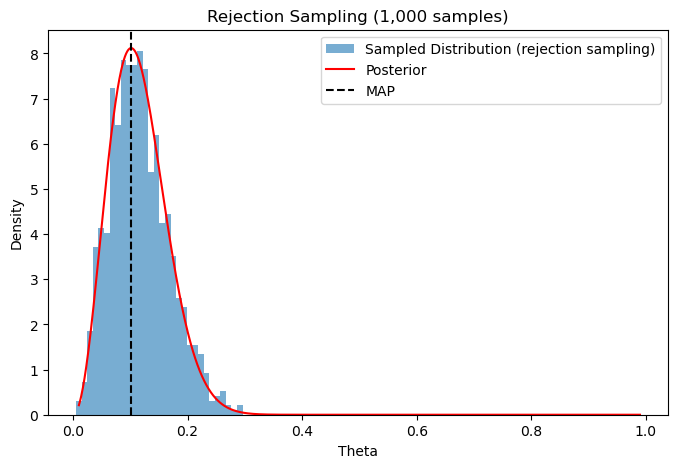

In [244]:
# plot rejection sampling results
plt.figure(figsize=(8, 5))

plt.hist(samples, bins=30, density=True, alpha=0.6, label="Sampled Distribution (rejection sampling)")

# plot the posterior for comparison to rejection samples 

# normalize posterior values so that the area under the curve is 1
# otherwise the plot won't line up 
posterior_values /= np.trapz(posterior_values, theta_values)
plt.plot(theta_values, posterior_values, label="Posterior", color="red")

# plot the MAP
plt.axvline(theta_map, color="black", linestyle="--", label="MAP")

plt.xlabel("Theta")
plt.ylabel("Density")
plt.title("Rejection Sampling (1,000 samples)")
plt.legend()

plt.show()

In [245]:
np.max(samples).round(3)

0.296

In [246]:
# use rejection sampling to draw 1,000 samples from the posterior
# and plot the distribution of samples - CLEAN THIS CODE UP AND ADD MORE COMMENTS 

# code adapted from:https://medium.com/@roshmitadey/rejection-sampling-sampling-from-difficult-distributions-dbd17742a919

# define posterior (target) distribution
def posterior(theta):
    return np.exp(flip_log_posterior(theta))

# define proposal distribution (here, I'm proposing a uniform dist)
proposal_dist = stats.uniform(0,1) # instead of Beta 6, 45

# find M by maximizing f(theta)/g(theta) over a grid
theta_grid = np.linspace(0.01, 0.99, 1000)
posterior_values = np.array([posterior(theta) for theta in theta_grid])
proposal_values = proposal_dist.pdf(theta_grid)
M = max(posterior_values / proposal_values)

# rejection sampling
samples = []
num_samples = 10000 # test with 10,000 samples to see if that improves
# how well we capture the posterior 

while len(samples) < num_samples:
    y = proposal_dist.rvs()  # sample from Beta(3,40)
    u = np.random.uniform(0, 1)  # sample u ~ U(0,1)
    
    if u < posterior(y) / (M * proposal_dist.pdf(y)):
        samples.append(y)

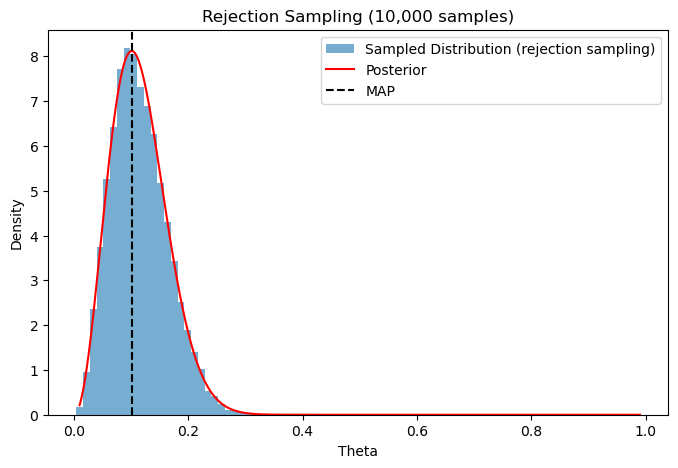

In [247]:
# plot rejection sampling results
plt.figure(figsize=(8, 5))

plt.hist(samples, bins=30, density=True, alpha=0.6, label="Sampled Distribution (rejection sampling)")

# plot the posterior for comparison to rejection samples 

# normalize posterior values so that the area under the curve is 1
# otherwise the plot won't line up 
posterior_values /= np.trapz(posterior_values, theta_values)
plt.plot(theta_values, posterior_values, label="Posterior", color="red")
#plt.plot(theta_values, proposal_values, label="Target PDF", color="green")

# plot the MAP
plt.axvline(theta_map, color="black", linestyle="--", label="MAP")

plt.xlabel("Theta")
plt.ylabel("Density")
plt.title("Rejection Sampling (10,000 samples)")
plt.legend()

plt.show()

**RESPONSE - Part (c):**

### **(d) Report the Expected Value of $\theta$ and the 90% Credible Interval**

In [248]:
# report the expected value and the 90% credible interval

# expected value
expected_value = np.mean(samples).round(3)

# 90% credible interval
lower_bound = np.percentile(samples, 5).round(3)
upper_bound = np.percentile(samples, 95).round(3)

print(f"Expected value: {expected_value}")
print(f"90% Credible Interval: ({lower_bound}, {upper_bound})")

Expected value: 0.115
90% Credible Interval: (0.043, 0.204)


**RESPONSE - Part (d):**

### **(e) Repeat Analysis with a Less Constrained Prior**

In [249]:
# repeat the analysis with a less constrained prior

# code below adapted from slide 23, class notes on Bayesian stats 

# step 0: define parameters of problem
n_students = 100
n_yes = 40  # number of "yes, I cheated" responses

# step 1: define the log-likelihood function 
def flip_ll(theta):

    p_yes = 0.5 * theta + 0.25  # probability of responding "yes"
    # 0.5 is the probability of the first coin flip being heads (truthful response)
    # 0.25 comes from the second flip (0.5 probability of tails, followed by 0.5 probability of heads -> p=0.25)

    # model the numner of "yes, I cheated" responses as a binomial RV
    log_likelihood = binom.logpmf(n_yes, n_students, p_yes) 
    return log_likelihood 

# step 2: define the prior -> here, using less constrained prior, Beta(20, 60)
def flip_log_prior(theta):
    beta_prior = np.log(stats.beta.pdf(theta, a=1, b=10)) # less constrained prior
    return beta_prior

# step 3: define the posterior
def flip_log_posterior(theta):
    # posterior is proportional to likelihood * prior (here, using logs, so sum)
    posterior = flip_ll(theta) + flip_log_prior(theta) 
    return posterior

In [250]:
# adapted from slide 23, class notes on Bayesian stats

# find the MAP by maximizing log posterior

# scipy.optimize.minimize documentation: https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html
result = minimize(lambda theta: -flip_log_posterior(theta), x0=0.1, bounds=[(0, 1)])
theta_map = result.x[0]

# compute posterior distribution for plotting
theta_values = np.linspace(0.01, 0.99, 1000) # grid approx approach (here, 1000 values between 0.01 and 0.99)

# compute the posterior values
# note: we exponentiate here because the posterior is in log form, 
# so convert back to normal space for plotting
posterior_values = np.exp([flip_log_posterior(theta) for theta in theta_values])

C:\Users\cms549\AppData\Local\Temp\ipykernel_42504\3117719558.py:22: RuntimeWarning: divide by zero encountered in log
  beta_prior = np.log(stats.beta.pdf(theta, a=1, b=10)) # less constrained prior


In [251]:
# use rejection sampling to draw 1,000 samples from the posterior
# and plot the distribution of samples - CLEAN THIS CODE UP AND ADD MORE COMMENTS 

# code adapted from:https://medium.com/@roshmitadey/rejection-sampling-sampling-from-difficult-distributions-dbd17742a919

# define posterior (target) distribution
def posterior(theta):
    return np.exp(flip_log_posterior(theta))

# define proposal distribution (here, I'm proposing to use a uniform distribution
# so we ensure we cover the dist)
proposal_dist = stats.uniform(0,1) # instead of Beta 6, 45

# find M by maximizing f(theta)/g(theta) over a grid
theta_grid = np.linspace(0.01, 0.99, 1000)
posterior_values = np.array([posterior(theta) for theta in theta_grid])
proposal_values = proposal_dist.pdf(theta_grid)
M = max(posterior_values / proposal_values)

# rejection sampling
samples = []
num_samples = 1000

while len(samples) < num_samples:
    y = proposal_dist.rvs()  # sample from proposal dist 
    u = np.random.uniform(0, 1)  # sample u ~ U(0,1)
    
    if u < posterior(y) / (M * proposal_dist.pdf(y)):
        samples.append(y)

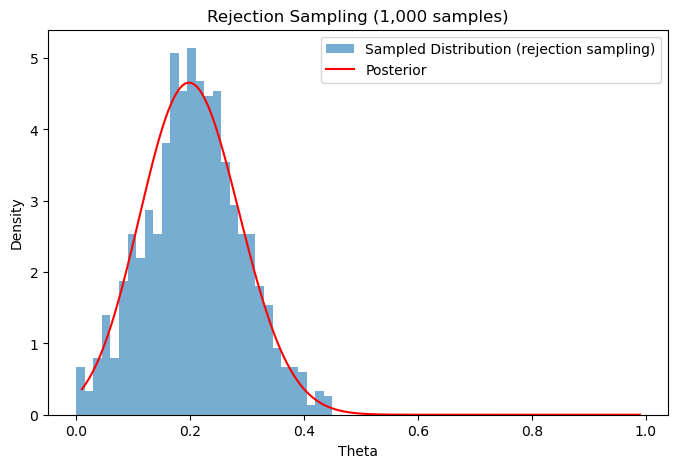

In [252]:
# plot rejection sampling results
plt.figure(figsize=(8, 5))

plt.hist(samples, bins=30, density=True, alpha=0.6, label="Sampled Distribution (rejection sampling)")

# plot the posterior for comparison to rejection samples 

# normalize posterior values so that the area under the curve is 1
# otherwise the plot won't line up 
posterior_values /= np.trapz(posterior_values, theta_values)
plt.plot(theta_values, posterior_values, label="Posterior", color="red")
#plt.plot(theta_values, proposal_values, label="Target PDF", color="green")

# plot the MAP
#plt.axvline(theta_map, color="black", linestyle="--", label="MAP")

plt.xlabel("Theta")
plt.ylabel("Density")
plt.title("Rejection Sampling (1,000 samples)")
plt.legend()

plt.show()

In [253]:
# report the expected value and the 90% credible interval
# for the less constrained prior example

# expected value
expected_value = np.mean(samples).round(3)

# 90% credible interval
lower_bound = np.percentile(samples, 5).round(3)
upper_bound = np.percentile(samples, 95).round(3)

print(f"Expected value (using less constrained prior): {expected_value}")
print(f"90% Credible Interval (using less constrained prior): ({lower_bound}, {upper_bound})")

Expected value (using less constrained prior): 0.207
90% Credible Interval (using less constrained prior): (0.063, 0.347)


**RESPONSE - Part (e):**

### Problem 2

You have been asked by a client to assess the risks of flooding to their
home (which is valued at \$400,000 and only floods when the stream water
levels exceed 1.5m). They would like to know the probability
distribution of annual flood damages to their home if they do not take
any preventative floodproofing measures. After some hydrologic analysis,
you have developed a 40-year record of annual maximum water levels (in
m) at the nearby stream.

You also have a depth-damage function for the fraction of the home’s
value which is damaged at varying flood depths:

$$d(h) = \mathbb{I}[h > 0] \frac{1}{1+\exp(-k(x-x_0))},$$

where $k=1.25$ and $x_0=2$[1]. The graph of this function is given in
the figure below.

[1] As a reminder, the indicator function $\mathbb{I}[h > 0]$ is $0$
when the condition is not satisfied (in this case, when $h=0$) and $1$
when it is satisfied.

**In this problem**:

-   Fit a log-normal distribution to the water depth data by maximizing
    likelihood.
-   Use 10,000 samples from this distribution to estimate the expected
    damages from an annual maximum flood event using Monte Carlo
    simulation. Report your estimate as well as its standard error.
    Would you want to use more samples? Why or why not?

In [254]:
# define the indicator function
def indicator_fn(h):
    return 1 if h > 0 else 0

# define the depth-damage function
def depth_damage_fn(h, k=1.25, x_0 = 2):
    d_h = indicator_fn(h)*1/(1+np.exp(-k*(h-x_0)))
    return d_h

### **(a) Fit a log-normal distribution to the water depth data by MLE**

In [ ]:
# code adapted below from homework #2, problem #1 for MLE

# load in the water depth data
water_depth_data = pd.read_csv("./data/water_depths.csv", sep = ",")

# fit a log-normal distribution to the water depth data by MLE
# extract depths from DataFrame
depths = water_depth_data["depths"].values  # convert to np array

# step 1: define the negative log-likelihood function for log-normal distribution
def neg_log_likelihood(params):
    mu, sigma = params
    log_likelihood = np.sum(stats.lognorm.logpdf(depths, s=sigma, scale=np.exp(mu)))
    return -log_likelihood  # negative log-likelihood for minimization

# step 2: set initial vals and bounds
p0 = [np.mean(np.log(depths)), np.std(np.log(depths))]  # initial values for mu and sigma
bounds = [(-np.inf, np.inf), (1e-5, np.inf)]  # bounds to ensure sigma > 0

# step 3: perform MLE (using scipy.optimize.minimize)
result = minimize(neg_log_likelihood, p0, bounds=bounds)

# extract estimated parameters
mu_hat, sigma_hat = result.x

print(f"Estimated Log-Normal Parameters: mu = {mu_hat:.4f}, sigma = {sigma_hat:.4f}")
print(f"MLE Log-Likelihood: {-result.fun:.2f}")

Estimated Log-Normal Parameters: mu = 0.1406, sigma = 0.2496
MLE Log-Likelihood: -6.87


### **(b) Monte Carlo Simulation (10,000 samples)**

In [ ]:
# use 10,000 samples from the above distribution to estimated
# the expected damages from an annual maximum flood event using MC simulation

# home value
home_value = 400000  # in dollars

# number of samples
num_samples = 10000

# step 1: generate samples from the fitted log-normal distribution above
flood_depth_samples = np.random.lognormal(mean=mu_hat, sigma=sigma_hat, size=num_samples)

# step 2: convert stream water levels to house-relative depth (not sure if correct)
house_elevation = 1.5  # house floods if water depth > 1.5 m
relative_depths = flood_depth_samples - house_elevation  # water depth above house elevation

# lol fix this??
damage_fractions = np.array([depth_damage_fn(h) for h in relative_depths])

# step 4: compute total damages
damages = damage_fractions * home_value

# step 5: compute expected annual damage
expected_damage = np.mean(damages)

print(f"Expected Annual Damage: ${expected_damage:.2f}")

Expected Annual Damage: $5815.44


In [259]:
# report the standard error of the estimate as well
# standard error = sigma_y/sqrt(n), where sigma_y is the sample standard deviation

standard_error = np.std(damages) / np.sqrt(num_samples)
print(f"Standard Error of Estimate: ${standard_error:.2f}")

Standard Error of Estimate: $146.96


### **(c) Assess whether to use more samples in Monte Carlo estimation**

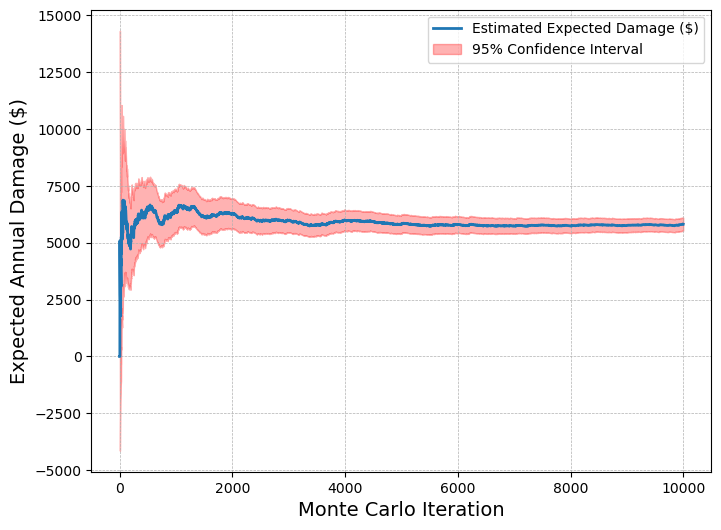

In [264]:
# to assess whether we need more samples, let's first plot
# how the Monte Carlo estimate converged after 10,000 samples

# adapted from Monte Carlo lecture, slide 32
# used ChatGPT co convert the Julia class code to Python 
# (see references)
# I made my own modifications to remove erreoneous code 

# number of Monte Carlo samples
nsamp = 10000

# initialize arrays to track stabilization
avg_mc_out = np.zeros(nsamp)
std_mc_out = np.zeros(nsamp)

# first iteration
avg_mc_out[0] = damages[0]
std_mc_out[0] = 0

# Monte Carlo estimate stabilization loop
for i in range(1, nsamp):
    avg_mc_out[i] = (avg_mc_out[i - 1] * i + damages[i]) / (i + 1)
    std_mc_out[i] = (1 / np.sqrt(i + 1)) * np.std(damages[: i + 1])

# plot results
plt.figure(figsize=(8, 6))

plt.plot(avg_mc_out, linewidth=2, label="Estimated Expected Damage ($)")
plt.fill_between(range(nsamp), avg_mc_out - 1.96 * std_mc_out, avg_mc_out + 1.96 * std_mc_out, 
                 color='red', alpha=0.3, label="95% Confidence Interval")

plt.xlabel("Monte Carlo Iteration", fontsize=14)
plt.ylabel("Expected Annual Damage ($)", fontsize=14)
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()

plt.show()

**RESPONSE: Based on the above graph, I would *not* use more samples (i.e., 10,000 samples seems sufficient). This is because the above graph shows the Monte Carlo iteration versus the expected annual damages, with the red band showing the 95% confidence interval. We see that after around 5,000 samples, the results have converged (i.e, the blue line has stabilized and the red band is pretty narrow), so at 10,000 samples, the blue line is still flat and the the red 95% confidence interval band is narrow. Although there is still some error left around 10,000 samples, with Monte Carlo simulation there is some amount of irreducible error, and in order to decrease the Monte Carlo error by 10%, we need 100x more samples, which does not seem necessary for this problem.**

### Problem 3

<span style="color:red;">GRADED FOR 5850 STUDENTS ONLY</span>

Next, your client would like advice on whether it would be
cost-effective to elevate their home to reduce flood risks. To address
this question, you will need to calculate the **net present value
(NPV)** of flooding damages, which converts damages over time to a
present value using a discount rate[1] For example, if your discount
rate is 4%, a dollar next year is worth the equivalent of about 96 cents
today. More generally, with a discount rate of $\gamma$ (as a decimal),
a dollar of benefits in $t$ years is worth $\$(1-\gamma)^t$ today.

The NPV of a sequence of money $x_t$ with discount rate $\gamma$ is the
sum of all of the discounted values, that is,

$$NPV = \sum_{t=0}^T x_t (1-\gamma)^t,$$

where $T$ is the time horizon. We’ll use a discount rate of 4% in this
problem, which is typical for this type of problem, and a design horizon
of 30 years.

For this problem, we will assume that the cost of elevating the house
$\Delta h$ m is
$C(\Delta h) = \mathbb{I}[h > 0](100,000 + 2,000\Delta h)$.

[1] Discount rates reduce future monetary values to reflect the
time-value of money; that is, you would rather have a bit less money
today than none today and more next year, as you could save or invest
that money. The actual choice of discount rates is the subject of much
economic theory and plays an important role in environmental
decision-making, particularly for multi-generational investments such as
climate mitigation. For example, with a relatively large discount rate
(such as 7%), all costs and benefits after a decade are effectively
zero, which means it never appears cost-effective to e.g. reduce fossil
fuel emissions.

> **Tip**
>
> Be careful about the quantity you’re estimating. Calculating the
> benefits of elevating by $\Delta h$ m requires calculating how the
> elevation *changes* the expected flooding damages over the design
> horizon *relative to a no-heightening baseline*.

**In this problem**:

-   Using the extreme water level distribution from Problem 2, use Monte
    Carlo simulation to estimate the NPV of the benefits of elevation
    levels between 0 and 5m (you don’t have to consider increments finer
    than 0.5m). What elevation heights pass the cost-benefit test? You
    can assume that the costs of elevation are all up front (that is, in
    year 0).
-   What height (including a possible elevation of 0m) maximizes the NPV
    of net benefits (benefits - ocsts)?[1]

[1] This is an example of **Monte Carlo optimization** as you are using
Monte Carlo simulation to estimate the optimization objective function.

## References and Generative AI Acknowledgement

"Rejection Sampling: Sampling from ‘difficult’ distributions". (2024). https://medium.com/@roshmitadey/rejection-sampling-sampling-from-difficult-distributions-dbd17742a919

OpenAI. (2025). ChatGPT (March 11) version) [Large language model]. https://openai.com/chatgpt [Accessed 11 March 2025]. 

- Problem 0: Setting up packages
    - Prompt I asked ChatGPT: "Convert these Julia packages to Python". That is, I asked it to convert the provided Julia packages to Python.

- Problem 2: Convert this code [the class code from slide 32 on Monte Carlo] to Python:

    `# show Monte Carlo estimate stabilization
    avg_mc_out = zeros(nsamp)
    avg_mc_out[1] = mean_SO2[1] > 0.14
    std_mc_out = zeros(nsamp)
    std_mc_out[1] = 0
    for i = 2:nsamp
        avg_mc_out[i] = (avg_mc_out[i-1] * (i-1) + (mean_SO2[i] > 0.14)) / i
        std_mc_out[i] = 1/sqrt(i) * std(mean_SO2[1:i] .> 0.14)
    end
    p = plot(avg_mc_out, xlabel="Monte Carlo Iteration", ylabel="Probability", left_margin=3mm, legend=:false, ribbon=1.96*std_mc_out, fillalpha=0.3, linewidth=2, tickfontsize=16, guidefontsize=18, fillcolor=:red, right_margin=5mm, minorgrid=true)
    ylims!(p, (0, 0.3))
    yaxis!(p, yminorticks=5)
    plot!(p, size=(600, 450))
    display(p)`